# Logistinen regressio malli 1
Logistinen regressio on tilastollinen luokittelumenetelmä, joka 
ennustaa todennäköisyyttä sille, kuuluuko havainto tiettyyn 
luokkaan. Se soveltuu hyvin binääriseen luokitteluun, kuten 
diabeteksen ennustamiseen.

Sama aineisto molemmissa malleissa:
- Malli 1: pitkäaikaissokeri mukana
- Malli 2: ilman pitkäaikaissokeria

## 1. Kirjastot ja data
Ladataan tarvittavat kirjastot ja luetaan aineisto sisään.

In [1]:
#!pip install statsmodels

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

In [3]:
df=pd.read_csv("database_original.csv")

## 2. Datan valmistelu

Osa muuttujista pudotetaan pois mallista korrelaatiomatriisin ja VIF-analyysin perusteella.
Korrelaatiomatriisin avulla tutkitaan muuttujien välisten 
lineaaristen yhteyksien voimakkuutta ja suuntaa. Arvot 
vaihtelevat välillä -1 ja 1:
Sininen -kuvaa positiivista korrelaatiota — mitä tummempi, sitä voimakkaampi yhteys
Punainen -kuvaa negatiivista korrelaatiota — mitä tummempi, sitä voimakkaampi käänteinen yhteys
Valkoinen  -tarkoittaa että lineaarista yhteyttä ei ole

VIF-analyysi tunnistaa monimuuttuja-multikollineaarisuuden. 
Kynnysarvona pidetään VIF > 10 — sen ylittävät muuttujat tulisi poistetaa. 
Diabetes jätetään VIF-analyysin ulkopuolelle, koska se on selitettävä muuttuja.


In [4]:
corr_matrix =df.corr()

<Axes: >

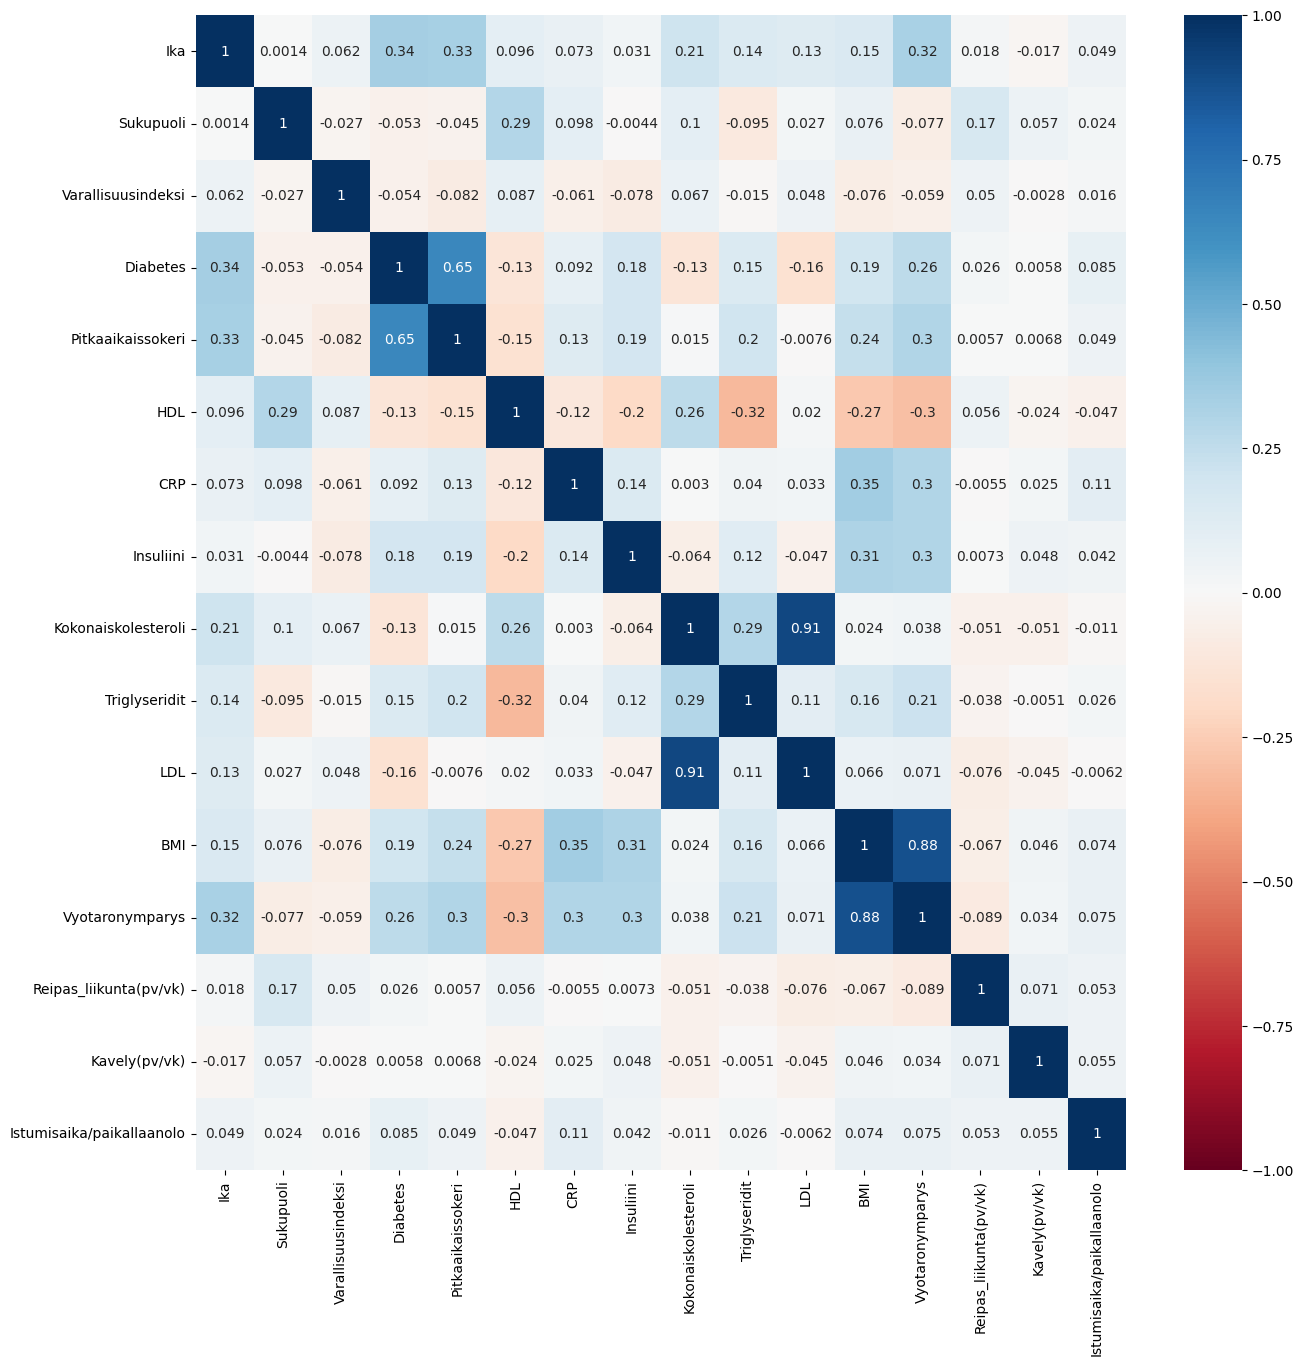

In [5]:
plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix, vmin = -1.0, vmax = 1.0, cmap ='RdBu', annot = True)

Tarkastellaan merkittävimpien muuttujien välisiä korrelaatioita:
- Kokonaiskolesteroli ja LDL korreloivat erittäin voimakkaasti (r=0.91)
- BMI ja vyötärönympärys korreloivat voimakkaasti (r=0.88)
- Diabetes ja pitkäaikaissokeri korreloivat odotetusti (r=0.65)
- HDL ja triglyseridit korreloivat negatiivisesti (r=-0.32)

Korrelaatiomatriisi tunnistaa muuttujien väliset parit, mutta 
ei kerro kokonaiskuvaa multikollinearisuudesta muutujien välillä — siksi 
tarkastellaan lisäksi VIF-analyysia.

In [6]:

X_vif = df.drop("Diabetes", axis=1) # Väliaikainen X vain VIF-tarkastelua varten (ilman Diabetesta)


vif_df = pd.DataFrame()
vif_df["Variables"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                 for i in range(X_vif.shape[1])]
vif_df


,Variables,VIF
0,Ika,8.073387
1,Sukupuoli,12.383842
2,Varallisuusindeksi,5.490339
3,Pitkaaikaissokeri,32.686024
4,HDL,70.060560
5,CRP,1.511522
6,Insuliini,1.599928
7,Kokonaiskolesteroli,710.146592
8,Triglyseridit,9.900095
9,LDL,278.921859


VIF-analyysi vahvistaa korrelaatiomatriisin havaintoja 
tunnistaen voimakasta multikollineaarisuutta:
- Kokonaiskolesteroli (VIF=710) ja LDL (VIF=279) — erittäin korkeat, poistetaan
- Vyötärönympärys (VIF=147) ja BMI (VIF=80) — korkeat, poistetaan
- HDL (VIF=70) — korkea, poistetaan
- Sukupuoli (VIF=12) ja pitkäaikaissokeri (VIF=33) — ylittävät kynnysarvon
Poistetaan alla osa muutujista, pois lukien pitkäaikaissokerin, joka pidetään mukana vielä.

In [7]:
df.drop(columns=['HDL', 'Insuliini', 'Kokonaiskolesteroli','BMI', 'Vyotaronymparys','Reipas_liikunta(pv/vk)', 'Kavely(pv/vk)'], inplace=True) #poistetaan nämä, jotta aineiston muuttujat ei vät korrwloisi likaa keskenään

In [8]:
corr_matrix =df.corr()

<Axes: >

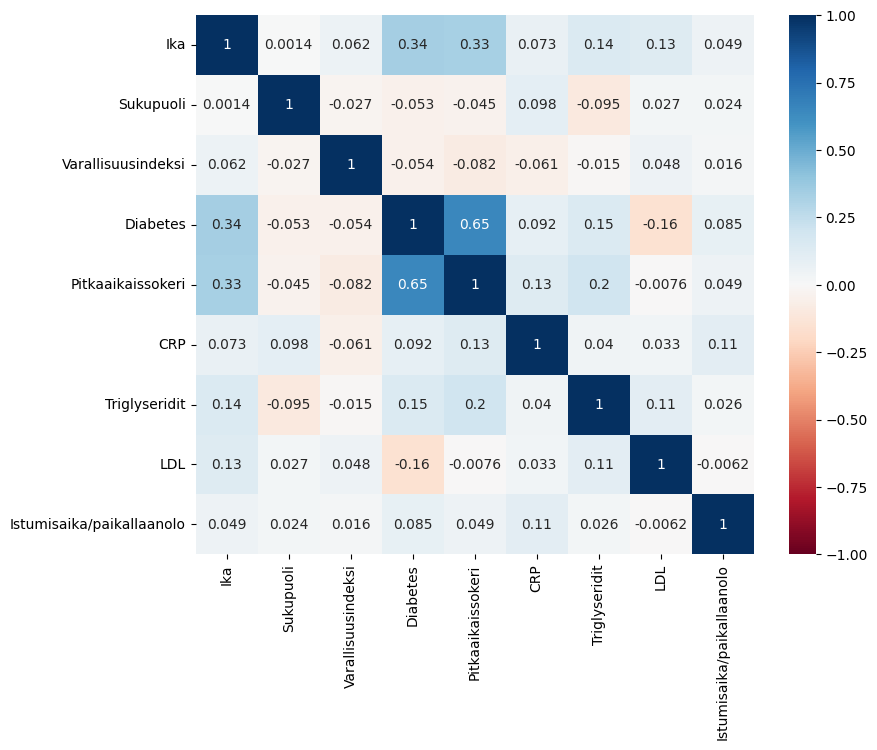

In [9]:
plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, vmin = -1.0, vmax = 1.0, cmap ='RdBu', annot = True)

Tarkastellaan merkittävimpien muuttujien välisiä korrelaatioita, osa muutujista poistettu mallista:
-diabetes ja pitkäaikaissokeri korreloivat edellen odotetusti (r=0.65), 
-diabetes ja ikä (r=0.34)
-pitkäaiakasissokeri ja ikä (r=0.3)
Muut muutujat korreloivat keskenään heikosti (-0.16-0.2)
Vaikka iän korrelaatio selitettävän muutujan (diabetes) kanssa ovat selvästi mekittäviä, se ei välttämättä aiheuta multikollinearisuus ongelmaa, vaan se oikeasti selittää selitettävää muutujaa. 

Korrelaatiomatriisi tunnistaa muuttujien väliset parit, mutta 
ei kerro kokonaiskuvaa multikollinearisuudesta muutujien välillä — siksi 
tarkastellaan lisäksi VIF-analyysia.

In [10]:
X_vif = df.drop("Diabetes", axis=1)
X_vif = pd.get_dummies(X_vif, drop_first=True)

vif_df = pd.DataFrame()
vif_df["Variables"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                 for i in range(X_vif.shape[1])]
vif_df

,Variables,VIF
0,Ika,7.021190
1,Sukupuoli,8.370342
2,Varallisuusindeksi,4.988504
3,Pitkaaikaissokeri,17.452024
4,CRP,1.361096
5,Triglyseridit,2.305389
6,LDL,8.765188
7,Istumisaika/paikallaanolo,1.431831


Vif-analyysin perusteella voidaan todeta, että kaikkien muiden paitsi pitkäaiakaisensokerin VIF-arvo on alle kymmenen ja siten hyäksyttävä. PIdetään se kuitenkin mukana mallissa 1 ja poistetaan se mallista 2 veratailun vuoksi, IKä, sukupuoli ja LDL ovat yli 5, joten niiden osalta multikollinearisuus on kohtuullista mutta ei kriittistä, joten ne pidetään mallissa.

In [11]:
y = df["Diabetes"] #selitettävä muuttuja
X = df.drop("Diabetes", axis=1) #selitettävät muutjat
X = pd.get_dummies(X, drop_first=True)

In [12]:
X_train, X_test, y_train, y_test =train_test_split( X, y, test_size=0.2, random_state = 42)

In [13]:
param_grid = {
    "scaler": [StandardScaler(), RobustScaler()],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"]
}

pipeline = Pipeline([
    ("scaler", StandardScaler()),  # placeholder, grid vaihtaa
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
grid.fit(X_train, y_train)
print("Paras scaler:", grid.best_params_["scaler"])
print("Paras C:", grid.best_params_["model__C"])
print("Paras AUC:", grid.best_score_)


/Users/einilevaslampi/Desktop/taitotalo_projektityo/nhanes-env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/einilevaslampi/Desktop/taitotalo_projektityo/nhanes-env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/einilevaslampi/Desktop/taitotalo_projektityo/nhanes-env/lib/python3.13/site-packages/sklearn/linear_m

Paras scaler: RobustScaler()
Paras C: 0.01
Paras AUC: 0.9591450330562307


/Users/einilevaslampi/Desktop/taitotalo_projektityo/nhanes-env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/einilevaslampi/Desktop/taitotalo_projektityo/nhanes-env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/einilevaslampi/Desktop/taitotalo_projektityo/nhanes-env/lib/python3.13/site-packages/sklearn/linear_m

In [14]:
y_train.value_counts().round(2)

Diabetes
0    2115
1     357
Name: count, dtype: int64

In [15]:
y_test.value_counts().round(2)


Diabetes
0    538
1     80
Name: count, dtype: int64

## 3. Mallin rakentaminen

Rakennetaan ensimmäinen logistinen regressiomalli diapeteksen tunnistmiseksi. Aineistossa on luokkaimbalanssi: 86% ei-diabeetikkoja ja 14% diabeetikkoja. Tämä korjataan käyttämällä class_weight='balanced' logistisessa regressiossa, jotta malli ei yliopi ennustamaan pelkästään ei-diabeetikkoja.

In [16]:
best_model = grid.best_estimator_
print("Paras malli:", grid.best_params_)

Paras malli: {'model__C': 0.01, 'model__penalty': 'l2', 'scaler': RobustScaler()}


Logistinen regressiomalli sovitetaan skaalattuun harjoitusaineistoon. Parametrina käytetään class_weight='balanced', joka antaa enemmän painoarvoa harvinaiselle lokalle eli diabetekselle. max_iter = 1000 varmistaa , että malli ehtii konvergoitua.

In [17]:
lr_model = best_model.named_steps['model']

print('intercept:', lr_model.intercept_)
print('Coefficient:', lr_model.coef_)
print()
coef_df = pd.DataFrame({
    'Muuttuja': X.columns,
    'Kerroin': lr_model.coef_[0]
}).sort_values('Kerroin', ascending=False)
print(coef_df)


intercept: [-1.54906315]
Coefficient: [[ 0.71643329 -0.06695913 -0.05787704  1.15938503  0.02007302  0.05142333
  -0.5123202   0.05978467]]

                    Muuttuja   Kerroin
3          Pitkaaikaissokeri  1.159385
0                        Ika  0.716433
7  Istumisaika/paikallaanolo  0.059785
5              Triglyseridit  0.051423
4                        CRP  0.020073
2         Varallisuusindeksi -0.057877
1                  Sukupuoli -0.066959
6                        LDL -0.512320


Kertoimien perusteella ikä, pitkäaikaissokeri ovat vahvimmin diabetestä riskiä lissäviä. Istumisaika, triglyseridit ja CRP lisäävät hieman riskiä. LDL, varallisuusindeksi ja sukupuoli vähentävät diabeteksen riskiä hieman. Intercept kuvaa diabeteksen perustodennäköisyyttä, kun kaikki muuttujat ovat nolla.

## 4. Mallin arviointi

Arvioidaan mallin suorituskyky testidatalla. Koska aineistossa on 
luokkaimbalanssi, pelkkä tarkkuus (accuracy) ei riitä — tarkastellaan 
myös ROC-AUC, confusion matrix ja classification report. ROC-AUC kertoo kuinka hyvin malli erottaa diabeteksen ei diabeteksestä:

### 4.1 Ennustetut todennäköisyydet ja jakauma

In [18]:
#ennusteet: binaarinen ja jatkuva -tarvitaan mallin arvioinnissa alempana
Y_pred_probabilities = best_model.predict_proba(X_test)[:,1] # todennäköisyydet (0.0–1.0) -> käytetään ROC-käyrässä ja AUC:ssa
y_pred = best_model.predict(X_test) # binääriset ennusteet (0 tai 1) -> käytetään confusion matrixissa ja classification reportissa
Y_pred_probabilities


array([0.12447543, 0.16590958, 0.15004699, 0.15621352, 0.10890453,
       0.02916726, 0.05091083, 0.09456087, 0.12555985, 0.86778903,
       0.0882108 , 0.06353607, 0.14105111, 0.39396684, 0.08612139,
       0.3130946 , 0.54002212, 0.64246152, 0.03100643, 0.48417491,
       0.01491382, 0.18288512, 0.86687007, 0.06707496, 0.15383733,
       0.13824245, 0.21893534, 0.92168358, 0.52949315, 0.17467511,
       0.09760857, 0.1033432 , 0.35542433, 0.10625705, 0.09442689,
       0.14739091, 0.05473784, 0.32660516, 0.61775037, 0.05560214,
       0.08881102, 0.11124087, 0.13864973, 0.05625853, 0.05418496,
       0.65476333, 0.06583773, 0.03790197, 0.67448043, 0.15789917,
       0.42898613, 0.12719477, 0.99962218, 0.1493456 , 0.2043304 ,
       0.56697361, 0.96888075, 0.58565759, 0.1695695 , 0.81530956,
       0.03857308, 0.06020915, 0.08004946, 0.20964787, 0.41272348,
       0.09063314, 0.02806919, 0.14590354, 0.15141875, 0.42807136,
       0.33011369, 0.23285468, 0.10777426, 0.12668533, 0.25604

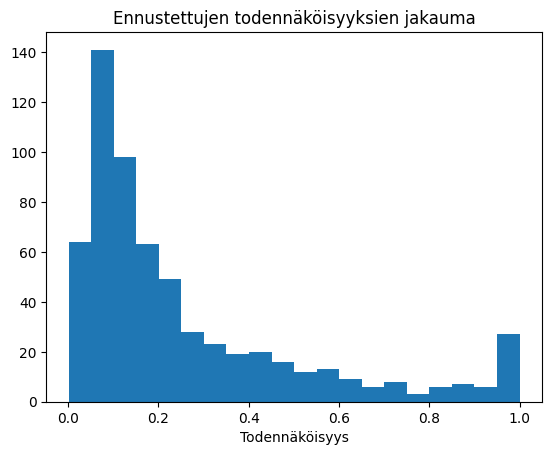

In [19]:
plt.hist(Y_pred_probabilities, bins=20)
plt.xlabel('Todennäköisyys')
plt.title('Ennustettujen todennäköisyyksien jakauma')
plt.show()

Jakauma on selvästi kaksihuippuinen — suuri piikki lähellä 
nollaa ja toinen lähellä ykköstä. Tämä kertoo että malli on 
varma ennusteissaan: se luokittelee henkilöt joko selvästi 
ei-diabeetikoiksi tai selvästi diabeetikoiksi, harvoin 
epävarmasti keskialueelle. Pitkäaikaissokeri ohjaa mallin 
päätöksiä voimakkaasti.

### 4.2 Log Loss
Mittaa kuinka tarkasti ja varmasti malli antaa todennäköisyyksiä.
Mitä lähempänä 0 sitä parempi:
- alle 0.3 → erinomainen
- 0.3–0.5 → hyvä
- yli 0.7 → heikko

In [20]:
logloss = log_loss(y_test, Y_pred_probabilities)
print(logloss)

0.25396174440427954


Arvo 0.228 on selvästi alle satunnaisen arvauksen tason (log(0.5) =0.693), mikä viittaa 
siihen että mallin todennäköisyysennusteet ovat melko tarkkoja ja virhe kustakin havainnosta jää keskimäärin pieneksi.

Tulos on odotetusti hyvä pitkäaikaissokerin ollessa mukana

### 4.3 AUC ja ROC-käyrä
ROC-käyrä kuvaa mallin erottelukykyä eri kynnysarvoilla.
AUC mittaa mallin kykyä erotella diabeetikot ei-diabeetikoista 
eri päätöskynnysarvoilla. Arvo 1.0 on täydellinen ja 0.5 
vastaa satunnaista arvausta.

- 0.9–1.0 → erinomainen
- 0.8–0.9 → hyvä  
- 0.7–0.8 → kohtalainen

In [21]:
auc = roc_auc_score(y_test, Y_pred_probabilities)
print("AUC", auc)

AUC 0.954042750929368


### AUC = 0.953

AUC mittaa mallin kykyä erotella diabeeksen ei-diabeeteksestä
eri päätöskynnysarvoilla. Arvo 0.953 on erinomainen eli malli järjestää
diabeteksen todennäköisemmäksi kuin ei-diabeteksestä 95.3%.

Korkea AUC selittyy todennäköisesti pitkäaikaissokerin mukana ololla.

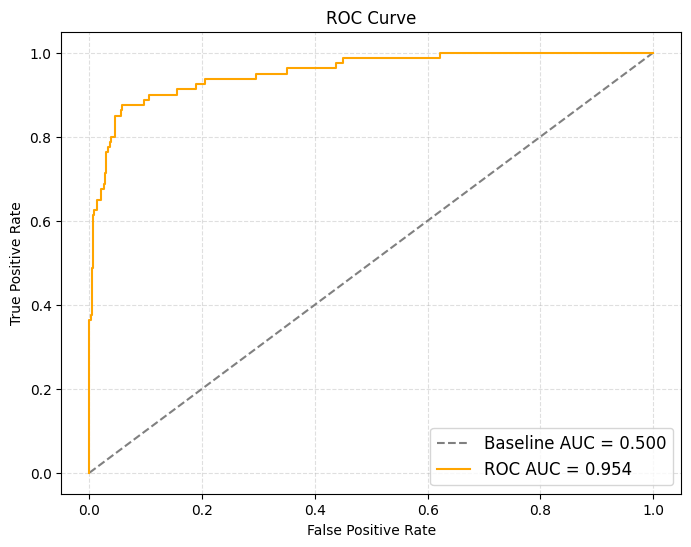

In [22]:

baseline_probs = [0 for _ in range(len(y_test))] # baseline-malli

Y_pred_probabilities = best_model.predict_proba(X_test)[:, 1] # mallin todennäköisyydet luokalle 1


baseline_auc = roc_auc_score(y_test, baseline_probs) # baseline AUC
pc_auc = roc_auc_score(y_test, Y_pred_probabilities) #predict_probalities AUC

# ROC-käyrän pisteet
baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_probs)
fpr, tpr, thresholds = roc_curve(y_test, Y_pred_probabilities, drop_intermediate=False)

# ROC-käyrä
plt.figure(figsize=(8,6))

plt.plot(
    baseline_fpr, baseline_tpr,
    linestyle='--', color='gray',
    label=f'Baseline AUC = {baseline_auc:.3f}'
)

plt.plot(
    fpr, tpr,
    color='orange',
    label=f'ROC AUC = {pc_auc:.3f}'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()


### ROC-käyrä ja AUC = 0.953

ROC-käyrä kuvaa mallin herkkyyttä (True Positive Rate) suhteessa 
vääriin hälytyksiin (False Positive Rate) eri kynnysarvoilla.

Käyrä nousee jyrkästi vasempaan yläkulmaan eli malli tunnistaa diabetekse hyvin pienellä määrällä vääriä 
positiivisia. AUC = 0.953 on selvästi baseline-arvon (0.5) 
yläpuolella. Tulos on odotetusti korkea pitkäaikaissokerin ollessa mukana mallissa.

### 4.4 Tilastollinen tarkastelu 

In [23]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n",cm)
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy = %.3f" % (accuracy)) 
print("\nClassification report\n")
print(classification_report(y_test, y_pred))

Confusion matrix:
 [[509  29]
 [ 12  68]]

Accuracy = 0.934

Classification report

              precision    recall  f1-score   support

           0       0.98      0.95      0.96       538
           1       0.70      0.85      0.77        80

    accuracy                           0.93       618
   macro avg       0.84      0.90      0.86       618
weighted avg       0.94      0.93      0.94       618



### Confusion Matrix ja Classification Report

Malli tunnistaa 86% diabeeteksestä oikein (recall=0.86), mikä on 
kliinisesti tärkein mittari — väärät negatiiviset tapaukset ovat 
haitallisempia kuin väärät positiiviset.
Precision 0.61 tarkoittaa, että  malli tuottaa jonkin verran 
turhia hälytyksiä, mikä on hyväksyttävää seulontamallissa, jossa 
tavoitteena on löytää kaikki riskiryhmään kuuluvat.

Kokonaistarkkuus (accuracy=0.91) on korkea, mutta luokkaimbalanssi 
heikentää mallin arviointia  ja siksi recall ja precision  ovat tärkeimpiä mittareitä tässä tutkimuksessa.

In [24]:

# Haetaan skaalattu data pipelinesta statsmodels-analyysia varten
scaler = best_model.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)

In [25]:
x_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

In [26]:
x_train_scaled_df= x_train_scaled_df.reset_index(drop=True) #synkronoidaan 
y_train= y_train.reset_index(drop=True)

X1 = sm.add_constant(x_train_scaled_df) #lisätään vakiotermi

logreg = sm.Logit(y_train,X1).fit() #luodaan lositinen

logreg.params
print(logreg.summary())

Optimization terminated successfully.
         Current function value: 0.181610
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               Diabetes   No. Observations:                 2472
Model:                          Logit   Df Residuals:                     2463
Method:                           MLE   Df Model:                            8
Date:                Wed, 01 Apr 2026   Pseudo R-squ.:                  0.5602
Time:                        00:47:23   Log-Likelihood:                -448.94
converged:                       True   LL-Null:                       -1020.7
Covariance Type:            nonrobust   LLR p-value:                1.533e-241
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -3.6501      0.182    -20.026      0.000      -4.

Pseudo R² = 0.560 viittaa erinomaiseen mallin sopivuuteen.

Tilastollisesti merkitsevät muuttujat (p < 0.05):
- Ikä (p<0.001): ikä lisää diabetesriskiä merkittävästi
- Pitkäaikaissokeri (p<0.001): vahvin yksittäinen ennustaja
- LDL (p<0.001): negatiivinen yhteys — vaatii lisätarkastelua(intuittivisesti ei looginen)
- Istumisaika (p=0.011): istuva elämäntapa lisää riskiä

Ei-merkitsevät muuttujat (p > 0.05): sukupuoli, 
varallisuusindeksi, CRP ja triglyseridit.


In [27]:
df_table = pd.DataFrame({"variable": logreg.params.index, "coef": logreg.params, "odds_ratio": np.exp(logreg.params.values), "p_value": logreg.pvalues})
print(df_table)

                                            variable      coef  odds_ratio  \
const                                          const -3.650089    0.025989   
Ika                                              Ika  1.789960    5.989211   
Sukupuoli                                  Sukupuoli -0.015994    0.984134   
Varallisuusindeksi                Varallisuusindeksi -0.147871    0.862542   
Pitkaaikaissokeri                  Pitkaaikaissokeri  1.311054    3.710081   
CRP                                              CRP  0.012627    1.012707   
Triglyseridit                          Triglyseridit  0.030627    1.031101   
LDL                                              LDL -0.919752    0.398618   
Istumisaika/paikallaanolo  Istumisaika/paikallaanolo  0.056767    1.058409   

                                p_value  
const                      3.250110e-89  
Ika                        1.476428e-17  
Sukupuoli                  9.284015e-01  
Varallisuusindeksi         4.279892e-01  
Pitkaaika

### Odds Ratio

Tulkintasääntö:

Odds ratio > 1 → muuttuja lisää riskiä
Odds ratio = 1 → ei vaikutusta
Odds ratio  < 1 → muuttuja vähentää riskiä

Kuvaa muuttujan vaikutuksen voimakkuutta diabetesriskiin.
Keskeisimmät havainnot:
-Ikä (OR=5.99): vahvin riskitekijä — ikä lähes 6-kertaistaa diabetesriskin
-Pitkäaikaissokeri (OR=3.71): kohonnut HbA1c lähes nelinkertaistaa diabetesriskin
-Istumisaika (OR=1.06): istuva elämäntapa lisää riskiä lievästi
-LDL (OR=0.40): negatiivinen yhteys — vähentää riskiä tässä mallissa, mutta on ristiriitainen aikaisempien terveystutkimusten tietojen mukaan